<a href="https://colab.research.google.com/github/vidyadharne08-byte/CSL701-CS-12_Machine-Learning-Lab/blob/main/Another_copy_of_cs12_ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Vidya Rajan Dharne
Roll No : CS12
Batch : CS1

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


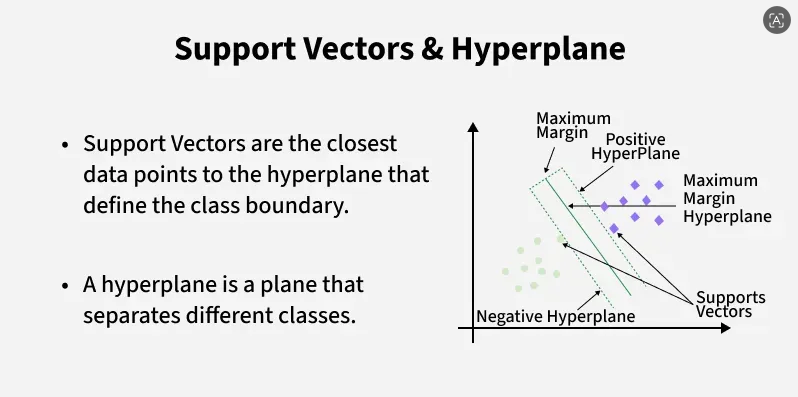
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Task 2: Explore the Dataset

In [ ]:
# Task 2: Explore the Dataset

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nDataset Shape:")
print("Number of observations:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFirst 10 Records:")
print(X[:10])

print("\nFirst 10 Target Values:")
print(y[:10])

df = pd.DataFrame(X, columns=iris.feature_names)

print("\nStatistical Summary:")
print(df.describe())

print("\nClass Distribution:")

unique, counts = np.unique(y, return_counts=True)

for class_value, count in zip(unique, counts):
    print(iris.target_names[class_value], ":", count)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
Number of observations: 150
Number of features: 4

First 10 Records:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]

First 10 Target Values:
[0 0 0 0 0 0 0 0 0 0]

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000         

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Task 3: Select Features and Target

# Select Petal Length and Petal Width
X_selected = X[:, [2, 3]]

# Select target
y_selected = y

# Display selected features
print("Selected Features:")
print("1. Petal Length")
print("2. Petal Width")

# Display shapes
print("\nFeature Matrix Shape:", X_selected.shape)
print("Target Shape:", y_selected.shape)

# Display first 5 records
print("\nFirst 5 Selected Records:")
print(X_selected[:5])

print("\nFirst 5 Target Values:")
print(y_selected[:5])

Selected Features:
1. Petal Length
2. Petal Width

Feature Matrix Shape: (150, 2)
Target Shape: (150,)

First 5 Selected Records:
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]

First 5 Target Values:
[0 0 0 0 0]


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
# Task 4: Split and Scale the Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_selected,
    test_size=0.20,
    random_state=42,
    stratify=y_selected
)

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display the shapes
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

# Display first 5 scaled training records
print("\nFirst 5 Scaled Training Records:")
print(X_train_scaled[:5])

Training Data Shape: (120, 2)
Testing Data Shape: (30, 2)
Training Target Shape: (120,)
Testing Target Shape: (30,)

First 5 Scaled Training Records:
[[-1.34572231 -1.32327558]
 [ 0.41450518  0.6517626 ]
 [ 0.58484978  0.25675496]
 [-1.28894078 -1.45494479]
 [ 0.13059752  0.12508575]]


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
# Task 5: Implement Linear SVM

from sklearn.svm import SVC

# Create Linear SVM model
linear_svm = SVC(kernel='linear', C=1.0)

# Train the model
linear_svm.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred_linear = linear_svm.predict(X_test_scaled)

# Display predictions
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred_linear)

# Display support vectors
print("\nNumber of Support Vectors for each class:")
print(linear_svm.n_support_)

print("\nTotal Number of Support Vectors:")
print(len(linear_svm.support_))

Actual Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted Values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]

Number of Support Vectors for each class:
[ 2 12 10]

Total Number of Support Vectors:
24


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [ ]:
# Task 6: Evaluate SVM

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
Accuracy (%): 96.66666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

Shape of 2-D dataset: (150, 2)
Training data shape: (120, 2)
Testing data shape: (30, 2)


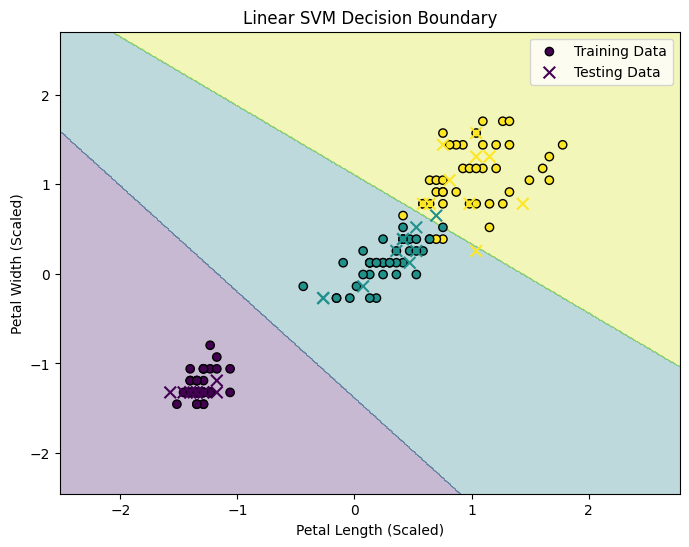

In [ ]:
# Task 7: Visualize SVM Decision Boundary

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# --------------------------------------------------
# 1. Create the 2-D Dataset
# --------------------------------------------------

# Select Petal Length and Petal Width
X_2D = X[:, [2, 3]]

# Target variable
y_2D = y

print("Shape of 2-D dataset:", X_2D.shape)


# --------------------------------------------------
# 2. Split the Data
# --------------------------------------------------

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.2,
    random_state=42,
    stratify=y_2D
)

print("Training data shape:", X_train_2D.shape)
print("Testing data shape:", X_test_2D.shape)


# --------------------------------------------------
# 3. Scale the Data
# --------------------------------------------------

scaler_2D = StandardScaler()

X_train_2D_scaled = scaler_2D.fit_transform(X_train_2D)
X_test_2D_scaled = scaler_2D.transform(X_test_2D)


# --------------------------------------------------
# 4. Train SVM using Linear Kernel
# --------------------------------------------------

svm_2D = SVC(kernel='linear', random_state=42)

svm_2D.fit(X_train_2D_scaled, y_train_2D)


# --------------------------------------------------
# 5. Create Mesh Grid
# --------------------------------------------------

x_min = X_train_2D_scaled[:, 0].min() - 1
x_max = X_train_2D_scaled[:, 0].max() + 1

y_min = X_train_2D_scaled[:, 1].min() - 1
y_max = X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


# --------------------------------------------------
# 6. Predict for Each Point in the Grid
# --------------------------------------------------

Z = svm_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


# --------------------------------------------------
# 7. Plot Decision Boundary
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training data
plt.scatter(
    X_train_2D_scaled[:, 0],
    X_train_2D_scaled[:, 1],
    c=y_train_2D,
    edgecolors='k',
    label='Training Data'
)

# Plot testing data
plt.scatter(
    X_test_2D_scaled[:, 0],
    X_test_2D_scaled[:, 1],
    c=y_test_2D,
    marker='x',
    s=70,
    label='Testing Data'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

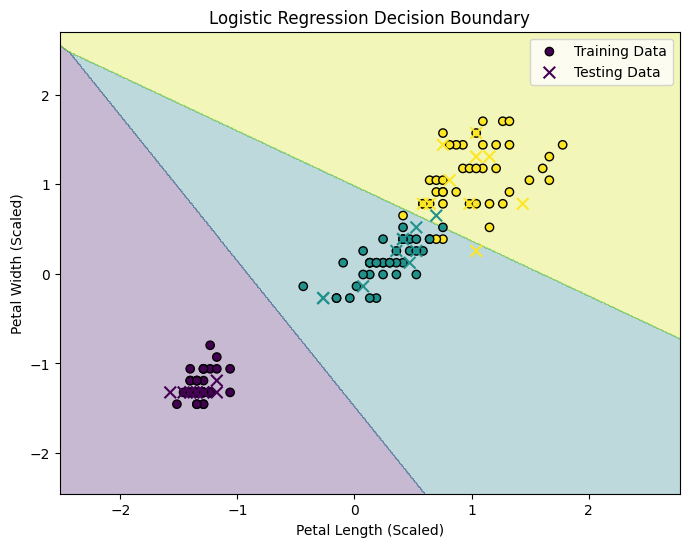

In [ ]:
## Task 8: Normal Linear Classification Boundary

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# --------------------------------------------------
# 1. Create the 2-D Dataset
# --------------------------------------------------

# Select Petal Length and Petal Width
X_2D = X[:, [2, 3]]

# Target variable
y_2D = y


# --------------------------------------------------
# 2. Split the Data
# --------------------------------------------------

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.2,
    random_state=42,
    stratify=y_2D
)


# --------------------------------------------------
# 3. Scale the Data
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_2D)
X_test_scaled = scaler.transform(X_test_2D)


# --------------------------------------------------
# 4. Train Logistic Regression
# --------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train_2D)


# --------------------------------------------------
# 5. Create Mesh Grid
# --------------------------------------------------

x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


# --------------------------------------------------
# 6. Predict Classes for Mesh Grid
# --------------------------------------------------

Z = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)


# --------------------------------------------------
# 7. Visualize Decision Boundary
# --------------------------------------------------

plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

# Training data
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train_2D,
    edgecolors='k',
    label='Training Data'
)

# Testing data
plt.scatter(
    X_test_scaled[:, 0],
    X_test_scaled[:, 1],
    c=y_test_2D,
    marker='x',
    s=70,
    label='Testing Data'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

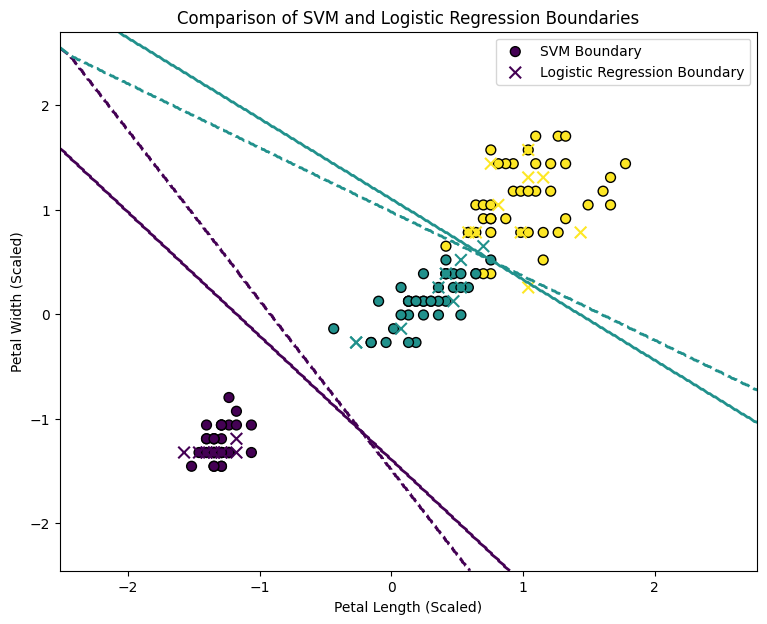

In [ ]:
# Task 9: Compare SVM and Logistic Regression Boundaries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


# --------------------------------------------------
# 1. Create the 2-D Dataset
# --------------------------------------------------

# Petal Length and Petal Width
X_2D = X[:, [2, 3]]
y_2D = y


# --------------------------------------------------
# 2. Split the Data
# --------------------------------------------------

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.2,
    random_state=42,
    stratify=y_2D
)


# --------------------------------------------------
# 3. Scale the Data
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_2D)
X_test_scaled = scaler.transform(X_test_2D)


# --------------------------------------------------
# 4. Train Linear SVM
# --------------------------------------------------

svm_model = SVC(
    kernel='linear',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train_2D)


# --------------------------------------------------
# 5. Train Logistic Regression
# --------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train_2D)


# --------------------------------------------------
# 6. Create Mesh Grid
# --------------------------------------------------

x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# --------------------------------------------------
# 7. Predict Using Both Models
# --------------------------------------------------

Z_svm = svm_model.predict(grid)
Z_svm = Z_svm.reshape(xx.shape)

Z_lr = logistic_model.predict(grid)
Z_lr = Z_lr.reshape(xx.shape)


# --------------------------------------------------
# 8. Plot Both Decision Boundaries
# --------------------------------------------------

plt.figure(figsize=(9, 7))

# SVM decision boundary
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=np.unique(Z_svm),
    linewidths=2
)

# Logistic Regression decision boundary
plt.contour(
    xx,
    yy,
    Z_lr,
    levels=np.unique(Z_lr),
    linestyles='--',
    linewidths=2
)

# Plot all data points
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train_2D,
    edgecolors='k',
    s=50,
    label='Training Data'
)

# Plot testing points
plt.scatter(
    X_test_scaled[:, 0],
    X_test_scaled[:, 1],
    c=y_test_2D,
    marker='x',
    s=70,
    label='Testing Data'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Comparison of SVM and Logistic Regression Boundaries")

plt.legend([
    "SVM Boundary",
    "Logistic Regression Boundary",
    "Training Data",
    "Testing Data"
])

plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:
# Task 10: Compare Performance

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# --------------------------------------------------
# 1. Make Predictions
# --------------------------------------------------

# Linear SVM predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Logistic Regression predictions
y_pred_lr = logistic_model.predict(X_test_scaled)


# --------------------------------------------------
# 2. Calculate Accuracy
# --------------------------------------------------

svm_accuracy = accuracy_score(y_test_2D, y_pred_svm)
lr_accuracy = accuracy_score(y_test_2D, y_pred_lr)

print("===== ACCURACY =====")
print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM Accuracy (%):", svm_accuracy * 100)

print("\nLogistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression Accuracy (%):", lr_accuracy * 100)


# --------------------------------------------------
# 3. Confusion Matrix
# --------------------------------------------------

svm_cm = confusion_matrix(y_test_2D, y_pred_svm)
lr_cm = confusion_matrix(y_test_2D, y_pred_lr)

print("\n===== CONFUSION MATRIX =====")

print("\nLinear SVM:")
print(svm_cm)

print("\nLogistic Regression:")
print(lr_cm)


# --------------------------------------------------
# 4. Classification Report
# --------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====")

print("\nLinear SVM:")
print(classification_report(y_test_2D, y_pred_svm))

print("\nLogistic Regression:")
print(classification_report(y_test_2D, y_pred_lr))

===== ACCURACY =====
Linear SVM Accuracy: 0.9333333333333333
Linear SVM Accuracy (%): 93.33333333333333

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy (%): 93.33333333333333

===== CONFUSION MATRIX =====

Linear SVM:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

===== CLASSIFICATION REPORT =====

Linear SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.